## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk

import os
from os import listdir
from os.path import isfile, join

import pandas as pd
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier

# Set the random seed for repeatability
np.random.seed(57)

## Image segmentation

### Open the NIfTI files and create one Numpy array per patient scan and one per segmentation mask.

In [2]:
# accessing individual image
image9 = sitk.ReadImage("module3/scans/case_9.nii")
arr9 = sitk.GetArrayViewFromImage(image9)

In [3]:
# iterating over all images and creating numpy array for each 
scans_path = "module3/scans"
image_array_data = {} # dictionary to store images and access them later

for dirpath, subdirs, filenames in os.walk(scans_path):
    for file in filenames:
        file_path = join(scans_path, file)
        key_i = file[:file.rfind(".")] #truncate to drop .nii, by finding the index of last occurrence of '.'
        image_i = sitk.ReadImage(file_path)
        image_array_data[f'{key_i}'] = sitk.GetArrayViewFromImage(image_i).copy()

# now we can access image data in array form for each image
image_array_data['case_9']

array([[[-2048, -2048, -2048, ..., -2048, -2048, -2048],
        [-2048, -2048, -2048, ..., -2048, -2048, -2048],
        [-2048, -2048, -2048, ..., -2048, -2048, -2048],
        ...,
        [-2048, -2048, -2048, ..., -2048, -2048, -2048],
        [-2048, -2048, -2048, ..., -2048, -2048, -2048],
        [-2048, -2048, -2048, ..., -2048, -2048, -2048]],

       [[-2048, -2048, -2048, ..., -2048, -2048, -2048],
        [-2048, -2048, -2048, ..., -2048, -2048, -2048],
        [-2048, -2048, -2048, ..., -2048, -2048, -2048],
        ...,
        [-2048, -2048, -2048, ..., -2048, -2048, -2048],
        [-2048, -2048, -2048, ..., -2048, -2048, -2048],
        [-2048, -2048, -2048, ..., -2048, -2048, -2048]],

       [[-2048, -2048, -2048, ..., -2048, -2048, -2048],
        [-2048, -2048, -2048, ..., -2048, -2048, -2048],
        [-2048, -2048, -2048, ..., -2048, -2048, -2048],
        ...,
        [-2048, -2048, -2048, ..., -2048, -2048, -2048],
        [-2048, -2048, -2048, ..., -2048, -20

In [4]:
# checking correct storage - intially, had issues
print(np.all(arr9 == sitk.GetArrayViewFromImage(sitk.ReadImage("module3/scans/case_9.nii"))))
print(np.all(image_array_data['case_9'] == sitk.GetArrayViewFromImage(sitk.ReadImage("module3/scans/case_9.nii"))))
print(np.all(arr9 == image_array_data['case_9']))


True
True
True


True


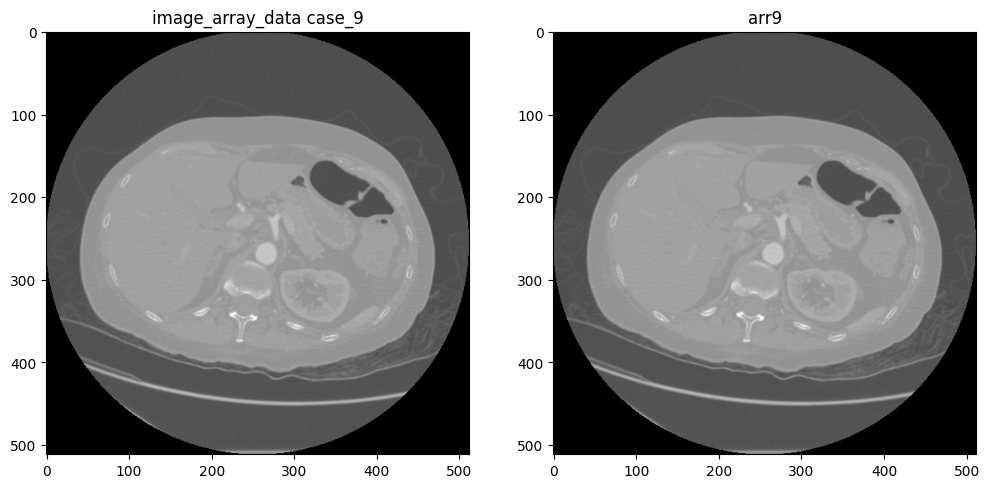

In [5]:
# visualize, to comfirm data preservance
slice_number = 0  # Example slice index to visualize
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(image_array_data['case_9'][slice_number], cmap='gray')
axs[0].set_title('image_array_data case_9')
axs[1].imshow(arr9[slice_number], cmap='gray')
axs[1].set_title('arr9')
print(np.all(arr9[slice_number]==image_array_data['case_9'][slice_number]))
plt.show()

In [6]:
# accessing individual mask
mask9 = sitk.ReadImage("module3/masks/case_9_mask.nii")
mask_arr9 = sitk.GetArrayViewFromImage(mask9)

In [7]:
# iterating over all images and creating numpy array for each mask
masks_path = "module3/masks"
mask_array_data = {} # dictionary to store masks and access them later

for dirpath, subdirs, filenames in os.walk(masks_path):
    for file in filenames:
        file_path = join(masks_path, file)
        image_i = sitk.ReadImage(file_path)
        array_i = sitk.GetArrayViewFromImage(image_i).copy()
        key_i = file[:file.rfind('.')] #truncate to drop .nii
        mask_array_data[f'{key_i}'] = array_i
        #print(np.all(array_i == mask_arr9))

# now we can access mask data in array form for each image
mask_array_data['case_9_mask']

np.allclose(mask_array_data['case_9_mask'], mask_arr9)

True

### Find the range of voxels (3D pixels) in which the segmentation exists for each patient.

In [8]:
# Find where segmentation mask exists for a patient
non_zero_indices = np.nonzero(mask_array_data['case_9_mask'])
min_z, min_y, min_x = np.min(non_zero_indices, axis=1)
max_z, max_y, max_x = np.max(non_zero_indices, axis=1)
bounds = ((min_z,max_z),(min_y,max_y),(min_x,max_x))

In [9]:
# define a function to find where segmentation mask exists
def segmentation_range(mask_array):
    """
    Calculate the voxel ranges for non-zero elements in a segmentation mask.

    This function takes a 3D numpy array (representing a segmentation mask), 
    finds the indices of non-zero voxels, and determines the minimum 
    and maximum voxel indices along each dimension (z, y, x) where the 
    segmentation is present.

    Parameters:
    mask_array: numpy.ndarray
    A 3D numpy array representing the segmentation mask.

    Returns:
    tuple: A tuple containing three tuples, each representing the 
    (min, max) range of indices for the z, y, and x dimensions, respectively.

    Example:
    z_range, y_range, x_range = segmentation_range(mask_array_data['case_9_mask'])
    """
    # Find the indices where segmentation is non-zero
    non_zero_indices = np.nonzero(mask_array)

    # Check if there are no non-zero indices
    if not non_zero_indices[0].size:
        # Return 0-range if no non-zero voxels are found
        return (0, 0), (0, 0), (0, 0)

    # Calculate the range for each dimension
    min_z, min_y, min_x = np.min(non_zero_indices, axis=1)
    max_z, max_y, max_x = np.max(non_zero_indices, axis=1)

    return (min_z, max_z), (min_y, max_y), (min_x, max_x)

In [10]:
# apply function to each mask, store in dictionary as before
# dictionary to store ranges
segmentation_ex_ranges = {}

# obtaining ranges for each image's mask
for key in mask_array_data:
    i3d_range = segmentation_range(mask_array_data[key]) #find range
    segmentation_ex_ranges[f'{key}'] = i3d_range #store with proper key

# now we can access them
segmentation_ex_ranges['case_37_mask']
segmentation_ex_ranges['case_9_mask']

((np.int64(108), np.int64(112)),
 (np.int64(238), np.int64(248)),
 (np.int64(387), np.int64(396)))

### Create a numpy array with a subvolume of the images by increasing 30 voxels in the x and y directions in both senses (min and max) and 5 in the z direction.

In [11]:
# extracting subvolume for a single image
# Padding values
padding_x = 30
padding_y = 30
padding_z = 5

# Calculate the padded boundaries
padded_min_x = max(min_x - padding_x, 0)
padded_max_x = min(max_x + padding_x, mask_array_data['case_9_mask'].shape[2] - 1)
padded_min_y = max(min_y - padding_y, 0)
padded_max_y = min(max_y + padding_y, mask_array_data['case_9_mask'].shape[1] - 1)
padded_min_z = max(min_z - padding_z, 0)
padded_max_z = min(max_z + padding_z, mask_array_data['case_9_mask'].shape[0] - 1)

subvolume = arr9[padded_min_z:padded_max_z+1,padded_min_y:padded_max_y+1,padded_min_x:padded_max_x+1]
print(f"Original dimension (for case_9) were: {arr9.shape}, segmented are {subvolume.shape}")

Original dimension (for case_9) were: (232, 512, 512), segmented are (15, 71, 70)


In [12]:
# function to extract subvolumes
def create_subvolume(image_array, boundary_indices, padding_x=30, padding_y=30, padding_z=5):
    """
    Create a subvolume of the image array with additional padding around
    the specified ranges.

    Parameters:
    image_array: (numpy.ndarray)
    The original 3D image in array form.
    
    boundary_indices: (tuple)
    A tuple of three tuples: ((min_z, max_z), (min_y, max_y), (min_x, max_x))

    padding_x: (int), optional
    A size of padding to apply in x-direction, default is 30

    padding_y: (int), optional
    A size of padding to apply in y-direction, default is 30

    padding_z: (int), optional
    A size of padding to apply in z-direction, default is 5

    Returns:
    numpy.ndarray: The extracted subvolume of the image array.

    Example: 
    subvolume = create_subvolume(image_array, segmentation_ex_ranges['case_9_mask'])
    """
    (min_z, max_z), (min_y, max_y), (min_x, max_x) = boundary_indices

    # Calculate padded boundaries, ensuring they are within image bounds
    padded_min_x = max(min_x - padding_x, 0)
    padded_max_x = min(max_x + padding_x, image_array.shape[2] - 1)

    padded_min_y = max(min_y - padding_y, 0)
    padded_max_y = min(max_y + padding_y, image_array.shape[1] - 1)

    padded_min_z = max(min_z - padding_z, 0)
    padded_max_z = min(max_z + padding_z, image_array.shape[0] - 1)

    # Extract the subvolume
    subvolume = image_array[padded_min_z:padded_max_z + 1, padded_min_y:padded_max_y + 1, padded_min_x:padded_max_x + 1]

    return subvolume

subvolume = create_subvolume(arr9, segmentation_ex_ranges['case_9_mask'])
subvolume.shape

(15, 71, 70)

In [13]:
# apply function to each image, store in dictionary as before
subvolumes_dict = {}

# obtaining ranges for each image's mask
for key in segmentation_ex_ranges:
    key_images = key[:key.rfind('_')] #truncate to drop _mask
    subvolume_i = create_subvolume(image_array_data[key_images], segmentation_ex_ranges[key]) 
    subvolumes_dict[f'{key_images}'] = subvolume_i #store with proper key

# now we can access them
subvolume_case_9 = subvolumes_dict['case_9']

True


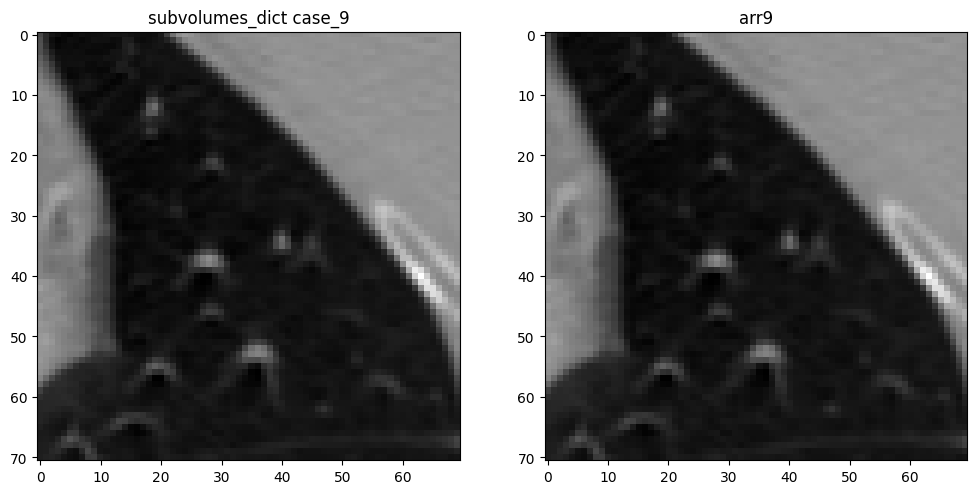

In [14]:
# checking the iterative process output matches individual image processing
slice_number = 0  # Example slice index to visualize, adjust as needed
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(subvolumes_dict['case_9'][slice_number], cmap='gray')
axs[0].set_title('subvolumes_dict case_9')
axs[1].imshow(subvolume[slice_number], cmap='gray')
axs[1].set_title('arr9')
print(np.all(subvolume[slice_number]==subvolumes_dict['case_9'][slice_number]))
plt.show()

### Create your own processing-based segmentation function using a simple thresholding algorithm. Apply your algorithm to the subvolumes created in the previous step. To do so, find the min/max of the intensities corresponding to voxels inside the segmentation to set a min/max threshold.

In [15]:
# find min/max of the intensities for voxels inside the segmentation for our single example
print("Initial image size:", arr9.shape)
print(f"Segmentation mask bounds: {bounds[0][0]}:{bounds[0][1]},{bounds[1][0]}:{bounds[1][1]},{bounds[2][0]}:{bounds[2][1]}")
cut = arr9[bounds[0][0]:bounds[0][1],bounds[1][0]:bounds[1][1],bounds[2][0]:bounds[2][1]]
print("Size of area of interest:",cut.shape)
print(f"Minimum intensity in area of interest is {np.min(cut)}, Maximum intensity is {np.max(cut)}.")

# create segmentation mask based on these min/max values
print("Applying mask to subvolume of shape:", subvolume.shape)
binary_mask_9 = ((subvolume >= np.min(cut)) & (subvolume <= np.max(cut))).astype(np.uint8)
print(binary_mask_9.shape)

true_mask_9 = create_subvolume(subvolume, segmentation_ex_ranges['case_9_mask'])

Initial image size: (232, 512, 512)
Segmentation mask bounds: 108:112,238:248,387:396
Size of area of interest: (4, 10, 9)
Minimum intensity in area of interest is -940, Maximum intensity is 76.
Applying mask to subvolume of shape: (15, 71, 70)
(15, 71, 70)


In [16]:
wrong = np.sum(binary_mask_9 != mask_array_data['case_9_mask'][padded_min_z:padded_max_z+1,padded_min_y:padded_max_y+1,padded_min_x:padded_max_x+1])
print(mask_array_data['case_9_mask'][padded_min_z:padded_max_z+1,padded_min_y:padded_max_y+1,padded_min_x:padded_max_x+1].shape)
print(binary_mask_9.shape)
print("Size of both is:", binary_mask_9.shape[0]*binary_mask_9.shape[1]*binary_mask_9.shape[2])
print("Percentage size of segmented part vs other:", ((cut.shape[0]*cut.shape[1]*cut.shape[2]) / (binary_mask_9.shape[0]*binary_mask_9.shape[1]*binary_mask_9.shape[2]))*100)
print("Percentage wrong:", wrong / (binary_mask_9.shape[0]*binary_mask_9.shape[1]*binary_mask_9.shape[2])*100)



(15, 71, 70)
(15, 71, 70)
Size of both is: 74550
Percentage size of segmented part vs other: 0.482897384305835
Percentage wrong: 92.38363514419852


In [17]:
# Segment the image based on voxel intensities corresponding in region of interest
def threshold_segmentation(image_array, subvolume, bounds):
    """
    Segments an image based on bounds of region of interest in which threshold values are calculated.
    
    Parameters:
    image_array: numpy.ndarray
    3D array representing the image.
    
    bounds: tuple
    A tuple of three tuples: ((min_z, max_z), (min_y, max_y), (min_x, max_x))

    subvolume: numpy.ndarray
    3D array representing the subset of an image, to apply the segmentation mask to.

    Returns:
    numpy.ndarray: a binary mask of the same shape as the input image, 
    where 1 indicates segmented voxels and 0 indicates non-segmented voxels.

    Example:
    our_segmented_9 = threshold_segmentation(arr9, mask_arr9, bounds)
    """
    z_min, z_max = bounds[0]
    y_min, y_max = bounds[1]
    x_min, x_max = bounds[2]

    if z_min == z_max:
        z_max = z_min + 1  # Adjust to include a single voxel

    # Use bounds to extract region of interest
    voxels = image_array[z_min:z_max, y_min:y_max, x_min:x_max]

    # first, find the min/max of the intensities corresponding to voxels inside the segmentation
    # to set a min/max threshold.
    if voxels.size == 0:
        print("No segmented voxels found.")
        return None, None
    min_intensity = np.min(voxels)
    max_intensity = np.max(voxels)

    # Then, create a binary mask based on the threshold
    binary_mask = ((subvolume >= min_intensity) & (subvolume <= max_intensity)).astype(np.uint8)

    return binary_mask

In [18]:
# checking if output of function is as desired
np.all(binary_mask_9 == threshold_segmentation(image_array_data["case_9"], subvolumes_dict["case_9"], segmentation_ex_ranges["case_9_mask"]))

np.True_

In [19]:
# now we apply our function to each image
our_masks_on_subvolumes = {}

for key in subvolumes_dict:
    key_ranges = key + "_mask"
    mask_i = threshold_segmentation(image_array_data[key], subvolumes_dict[key], segmentation_ex_ranges[key_ranges])
    our_masks_on_subvolumes[key] = mask_i

# now we can access masks directly
np.all(our_masks_on_subvolumes['case_9'] == binary_mask_9)

np.True_

### Compare your segmentations obtained with the thresholding algorithm and the ground truth ones. Is your method working as expected? Describe how you could improve it.

In [20]:
# function to trim truth masks to size of our masks/subvolumes (to be able to compare)
def trim_mask(mask, boundary_indices, padding_x=30, padding_y=30, padding_z=5):
    """
    Create a subvolume of the mask array with additional padding around
    the specified ranges.

    Parameters:
    mask: numpy.ndarray
    The original mask in array form.
    
    boundary_indices: tuple
    A tuple of three tuples: ((min_z, max_z), (min_y, max_y), (min_x, max_x))

    padding_x: (int), optional
    A size of padding to apply in x-direction, default is 30

    padding_y: (int), optional
    A size of padding to apply in y-direction, default is 30

    padding_z: (int), optional
    A size of padding to apply in z-direction, default is 5

    Returns:
    numpy.ndarray: The extracted subvolume of the mask array.

    Example: 
    truth_mask_9 = trim_mask(arr9, segmentation_ex_ranges['case_9_mask'])
    """
    (min_z, max_z), (min_y, max_y), (min_x, max_x) = boundary_indices

    # Calculate padded boundaries, ensuring they are within image bounds
    padded_min_x = max(min_x - padding_x, 0)
    padded_max_x = min(max_x + padding_x, mask.shape[2] - 1)

    padded_min_y = max(min_y - padding_y, 0)
    padded_max_y = min(max_y + padding_y, mask.shape[1] - 1)

    padded_min_z = max(min_z - padding_z, 0)
    padded_max_z = min(max_z + padding_z, mask.shape[0] - 1)

    # Extract the part of mask
    part_mask = mask[padded_min_z:padded_max_z + 1, padded_min_y:padded_max_y + 1, padded_min_x:padded_max_x + 1]

    return part_mask

truth_mask_9 = trim_mask(mask_array_data['case_9_mask'], segmentation_ex_ranges['case_9_mask'])
truth_mask_9.shape == binary_mask_9.shape

True

In [21]:
# trim all true masks
trimmed_true_masks = {}

for key in mask_array_data:
    mask_i = trim_mask(mask_array_data[key], segmentation_ex_ranges[key])
    trimmed_true_masks[key] = mask_i

# now we can access masks directly
np.all(trimmed_true_masks['case_9_mask'] == binary_mask_9) # not equal as our masks are not as great

np.False_

In [22]:
# we compare results of our segmentation algorithm to the ground truth segmentation
counter_correct = 0
counter_wrong = 0
list_rel_sizes = []

for key in our_masks_on_subvolumes:
    key_true = key + "_mask"
    correct = np.sum(trimmed_true_masks[key_true] == our_masks_on_subvolumes[key])
    counter_correct += correct
    incorrect = np.sum(trimmed_true_masks[key_true] != our_masks_on_subvolumes[key])
    counter_wrong += incorrect
    areaOfInterest_size = (segmentation_ex_ranges[key_true][0][1] - segmentation_ex_ranges[key_true][0][0]) * (segmentation_ex_ranges[key_true][1][1] - segmentation_ex_ranges[key_true][1][0]) * (segmentation_ex_ranges[key_true][2][1] - segmentation_ex_ranges[key_true][2][0])
    mask_size = trimmed_true_masks[key_true].shape[0] * trimmed_true_masks[key_true].shape[1] * trimmed_true_masks[key_true].shape[2]
    rel_size_of_areaOfInterest_to_mask = areaOfInterest_size / mask_size
    list_rel_sizes.append(rel_size_of_areaOfInterest_to_mask)

overall_accuracy = counter_correct / counter_wrong
avg_relative_size = np.mean(list_rel_sizes)
print("Overall accuracy:", overall_accuracy)
print("But average size of interest region to mask size is:", avg_relative_size)


Overall accuracy: 0.1016030950976845
But average size of interest region to mask size is: 0.03445282032848375


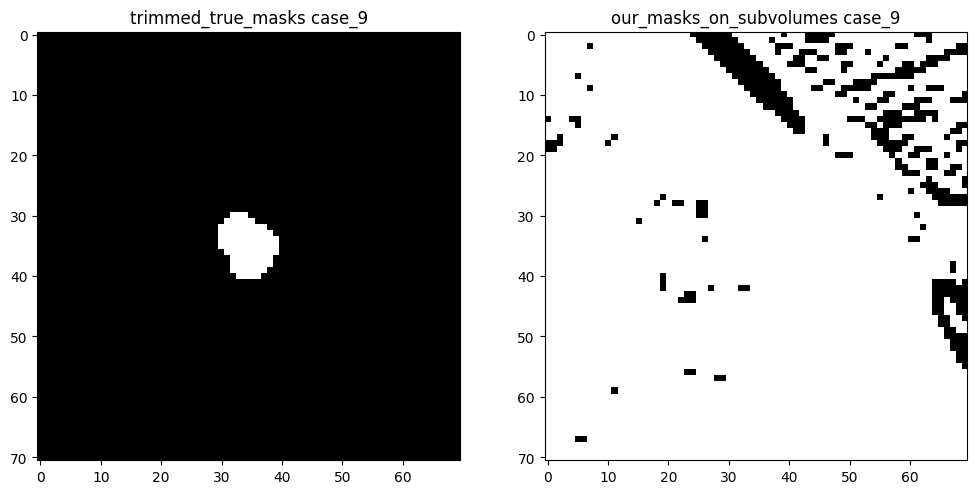

In [41]:
# visualizing differences
slice_number = 8  # Example slice index to visualize, adjust as needed
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(trimmed_true_masks['case_9_mask'][slice_number], cmap='gray')
axs[0].set_title('trimmed_true_masks case_9')
axs[1].imshow(our_masks_on_subvolumes['case_9'][slice_number], cmap='gray')
axs[1].set_title('our_masks_on_subvolumes case_9')
plt.show()

The method is working as expected: it successfully masks some of the image, but not all of it. Since these are medical images, in 3D, we can expect to see other features at other slices; therefore, we can not expect to perform an accurate segmentation solely by thresholding based on values in area of interest. 

There exist numerous ways to improve our custom segmentation process. Firstly, we can tighten the threshold boundaries if we want to observe only specific features. Secondly, we can use an Otsu algorithm which is based on finding the optimal separation value between background and object, based on image histogram. Furthermore, there exist numerous ML approaches, such as SVMs, k-means clustering and more.

## Image feature extraction and classification

In [24]:
# create a dictionary of images only of ROI (region of interest)
roi_dict = {}

# obtaining ranges for each image's mask
for key in segmentation_ex_ranges:
    key_images = key[:key.rfind('_')] # truncate to drop _mask
    roi_i = create_subvolume(image_array_data[key_images], segmentation_ex_ranges[key], 
                            padding_x=0, padding_y=0, padding_z=0) #without padding
    roi_dict[key_images] = roi_i #store with proper key

# now we can access them
roi_dict['case_9'].shape

(5, 11, 10)

### Write your own code to calculate each of the three features described above. In order to calculate the Uniformity, first you have to find the ranges of min-max intensities of the voxels and decide a sensible number of equally-spaced bins that works for all cases.

#### Calculating Energy

In [25]:
def calculate_energy(roi_voxels):
    """
    Calculate Energy radiomic feature.

    Parameters:
    roi_voxels: numpy.ndarray
    The voxel intensities inside the ROI.

    Returns:
    int: energy of the given ROI.
    """
    # Calculate Energy
    return np.sum(roi_voxels ** 2)

In [26]:
# create a dictionary of energy values
energy_dict = {}

# calculating energy for each image's roi
for key in roi_dict:
    E_i = calculate_energy(roi_dict[key])
    energy_dict[key] = E_i #store with proper key

# now we can access them
energy_dict['case_9']

np.int64(793747)

#### Calculating Mean Absolute Deviation (MAD)

In [27]:
def calculate_mad(roi_voxels):
    """
    Calculate Mean Absolute Deviation (MAD) radiomic feature.

    Parameters:
    roi_voxels: numpy.ndarray
    The voxel intensities inside the ROI.

    Returns:
    float: MAD of the given ROI.
    """
    mean = np.mean(roi_voxels) # Calculate mean of voxels in roi
    # Calculate MAD
    mad = np.mean(np.abs(roi_voxels - mean)) #thanks to numpy broadcasting
    return mad

In [28]:
# create a dictionary of MAD values
mad_dict = {}

# calculating MAD for each image's roi
for key in roi_dict:
    mad_i = calculate_mad(roi_dict[key])
    mad_dict[key] = mad_i #store with proper key

# now we can access them
mad_dict['case_9']

np.float64(266.9053553719008)

#### Calculating Uniformity

In [29]:
# calculating sensible number of bins

# ranges of values for each image roi
list_ranges = []
sizes = []
for key in roi_dict:
    min_i = np.min(roi_dict[key])
    max_i = np.max(roi_dict[key])
    count_i = roi_dict[key].size
    list_ranges.append((min_i, max_i)) #add to list
    sizes.append(count_i)

print(list_ranges)
print("Average min",np.mean(list_ranges[:][0]))
print("Average max",np.mean(list_ranges[:][1]))
print("Overall min",np.min(list_ranges))
print("Overall max",np.max(list_ranges))
print("Largest by size:", np.max(sizes))
print("Smallest by size:", np.min(sizes))
print("Average size:", np.mean(sizes))

[(np.int16(-993), np.int16(103)), (np.int16(-801), np.int16(51)), (np.int16(-855), np.int16(56)), (np.int16(-908), np.int16(-306)), (np.int16(-932), np.int16(415)), (np.int16(-1024), np.int16(1510)), (np.int16(-960), np.int16(189)), (np.int16(-1024), np.int16(272)), (np.int16(-1024), np.int16(293)), (np.int16(-1001), np.int16(160)), (np.int16(-963), np.int16(1009)), (np.int16(-919), np.int16(179)), (np.int16(-917), np.int16(50)), (np.int16(-1024), np.int16(473)), (np.int16(-1024), np.int16(1272)), (np.int16(-920), np.int16(214)), (np.int16(-912), np.int16(34)), (np.int16(-911), np.int16(1088)), (np.int16(-1024), np.int16(283)), (np.int16(-977), np.int16(840)), (np.int16(-1005), np.int16(680)), (np.int16(-1024), np.int16(140)), (np.int16(-969), np.int16(267)), (np.int16(-735), np.int16(58)), (np.int16(-933), np.int16(754)), (np.int16(-873), np.int16(21)), (np.int16(-1024), np.int16(121)), (np.int16(-909), np.int16(-423)), (np.int16(-1024), np.int16(341)), (np.int16(-1024), np.int16(893)

We choose number of bins equal to square root of average size of our ROI (slightly rounded down), i.e. $\sqrt10725\approx100$

In [30]:
def calculate_uniformity(roi_voxels):
    """
    Calculate Uniformity radiomic feature.

    Parameters:
    roi_voxels: numpy.ndarray
    The voxel intensities inside the ROI.

    Returns:
    float: uniformity measure of the given image's ROI.
    """
    num_bins = 100
    histogram, bin_edges = np.histogram(roi_voxels, bins=num_bins)
    N = roi_voxels.size
    # Normalize histogram
    p_i = histogram / N
    # Calculate Uniformity
    uniformity = np.sum(p_i ** 2)
    return uniformity

In [31]:
# create a dictionary of uniformity values
uniformity_dict = {}

# calculating uniformity for each image's roi
for key in roi_dict:
    unif_i = calculate_uniformity(roi_dict[key])
    uniformity_dict[key] = unif_i #store with proper key

# now we can access them
uniformity_dict['case_9']

np.float64(0.019649586776859504)

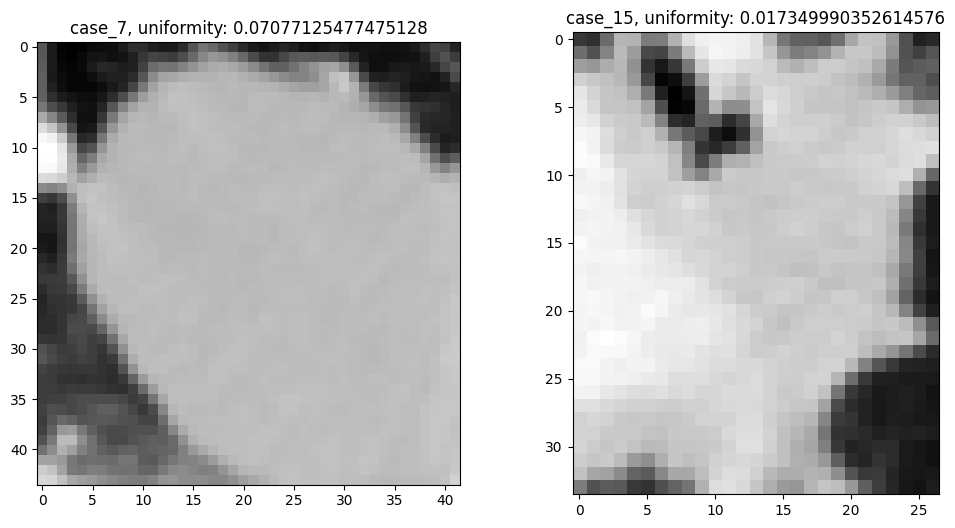

In [53]:
# visualizing
slice_number = 3  # Example slice index to visualize, adjust as needed
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(roi_dict['case_7'][slice_number], cmap='gray')
axs[0].set_title(f'case_7, uniformity: {uniformity_dict['case_7']}')
axs[1].imshow(roi_dict['case_2'][slice_number], cmap='gray')
axs[1].set_title(f'case_15, uniformity: {uniformity_dict['case_2']}')
plt.show()

### Which of those features would you use to classify between the benign and malignant lesions and why?

In [33]:
# we create a dataframe structure for easier operations on data

# Load csv file into a dataframe
df_csv = pd.read_csv("module3/labels.csv")

# rename ID column to match other data
df_csv['case_id'] = 'case_' + df_csv['ID'].astype(str)

# Convert dictionaries into DataFrames
df_E = pd.DataFrame(list(energy_dict.items()), columns=['case_id', 'E'])
df_mad = pd.DataFrame(list(mad_dict.items()), columns=['case_id', 'MAD'])
df_unif = pd.DataFrame(list(uniformity_dict.items()), columns=['case_id', 'uniformity'])

# Merge all DataFrames on 'case_id'
final_df = df_csv.merge(df_E, on='case_id', how='left')\
                .merge(df_mad, on='case_id', how='left')\
                .merge(df_unif, on='case_id', how='left')

In [34]:
final_df

,ID,Diagnosis,case_id,E,MAD,uniformity
0,0,2,case_0,587965,170.501076,0.030512
1,1,3,case_1,25813304,306.916718,0.025784
2,2,2,case_2,33071914,361.965321,0.017350
3,3,1,case_3,524076,220.304267,0.015886
4,4,3,case_4,739825,343.373241,0.023051
5,5,1,case_5,1080828,197.058105,0.018257
6,6,2,case_6,43087397,414.797942,0.027737
7,7,2,case_7,35621365,257.470498,0.070771
8,8,1,case_8,45747,157.959429,0.015520
9,9,1,case_9,793747,266.905355,0.019650


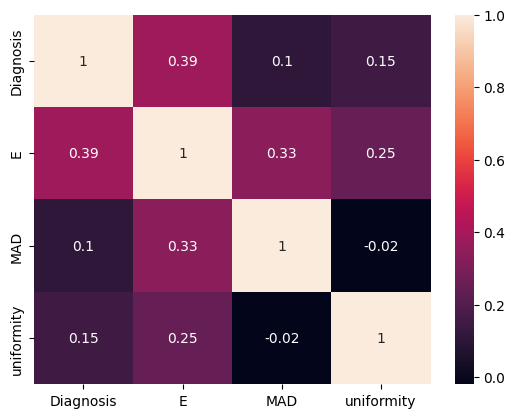

In [35]:
df_filtered = final_df.drop(columns=['case_id', 'ID']) #crop non-quantitative columns

correlation_matrix = df_filtered.corr()

# Visualizing the correlation matrix
sns.heatmap(correlation_matrix, annot=True)
plt.show()

In [36]:
# Split data into features and target
X = df_filtered.drop('Diagnosis', axis=1)
y = df_filtered['Diagnosis']

model = RandomForestClassifier()
model.fit(X, y)

importances = model.feature_importances_
feature_importance = pd.Series(importances, index=X.columns).sort_values(ascending=False)
print(feature_importance)

E             0.449024
uniformity    0.283511
MAD           0.267464
dtype: float64
